In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style('darkgrid')
sns.set_palette('viridis')

print("All libraries imported successfully!")
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Seaborn version:", sns.__version__)

All libraries imported successfully!
NumPy version: 2.4.6
Pandas version: 3.0.3
Seaborn version: 0.13.2


In [2]:
# Load iris dataset — built into seaborn just like tips!
df = sns.load_dataset('iris')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (150, 5)


              sepal_length  sepal_width  petal_length  petal_width
sepal_length          1.00        -0.12          0.87         0.82
sepal_width          -0.12         1.00         -0.43        -0.37
petal_length          0.87        -0.43          1.00         0.96
petal_width           0.82        -0.37          0.96         1.00


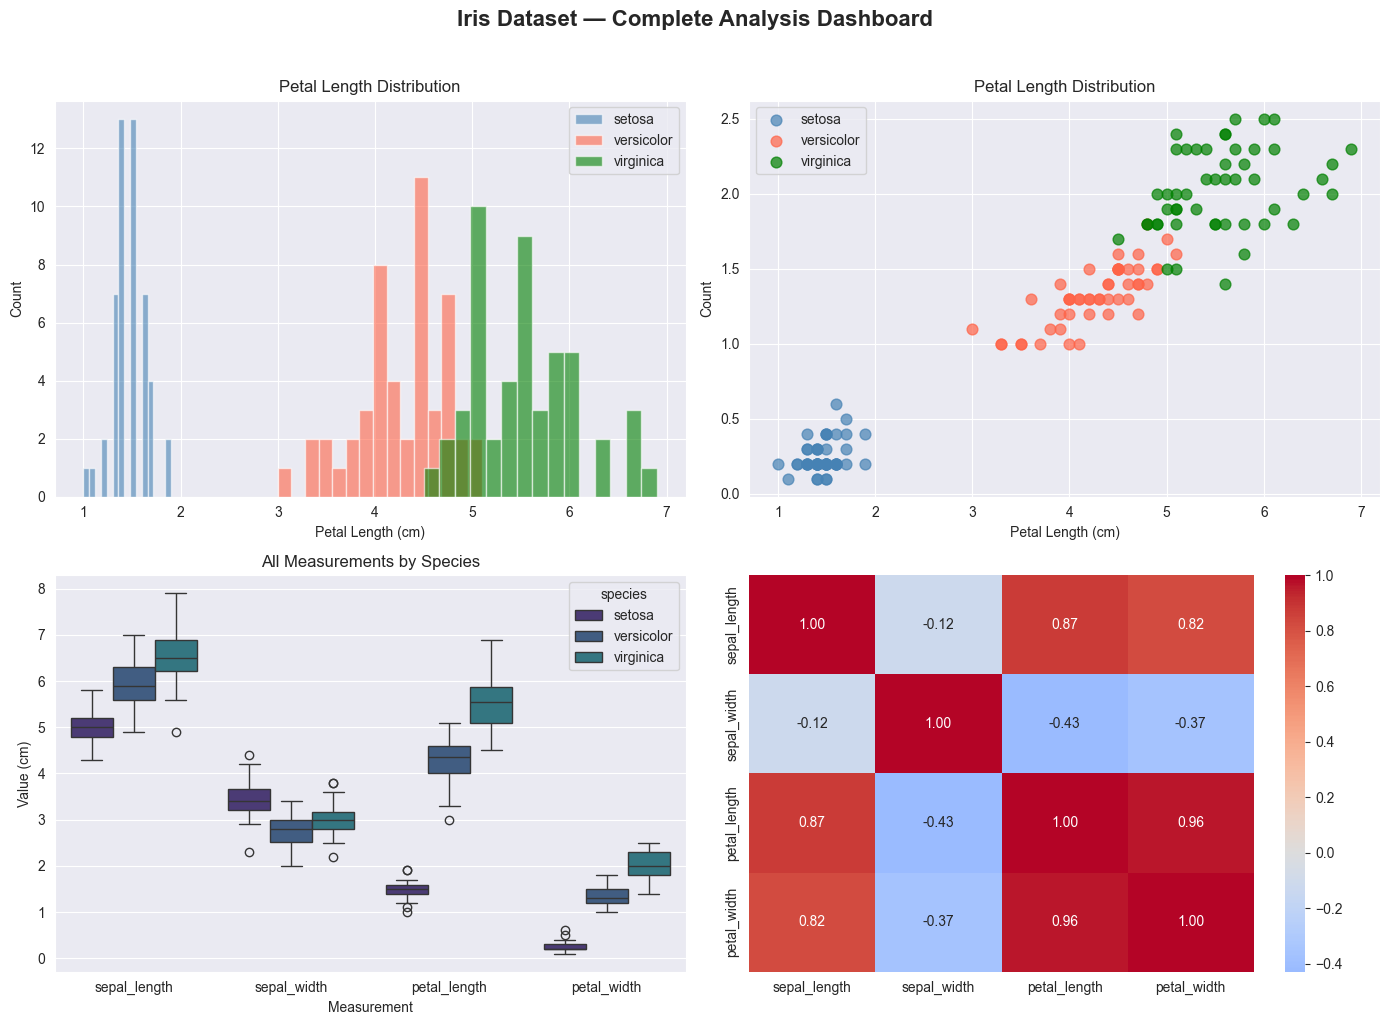

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Iris Dataset — Complete Analysis Dashboard', 
             fontsize=16, fontweight='bold', y=1.02)

colors = {'setosa': 'steelblue', 'versicolor': 'tomato', 'virginica': 'green'}

# ── Chart 1 — top left — Petal Length Distribution by Species ──
for species in ['setosa', 'versicolor', 'virginica']:
    data = df[df['species']==species]['petal_length']
    axes[0,0].hist(data, bins=15, alpha=0.6,
                   label=species, color=colors[species], edgecolor='white')
axes[0,0].set_title('Petal Length Distribution')
axes[0,0].set_xlabel('Petal Length (cm)')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()

# ── Chart 2 — top right — Scatter plot petal_length vs petal_width ──
for species, group in df.groupby('species'):
    axes[0,1].scatter(group['petal_length'], group['petal_width'],
               label=species,
               color=colors[species],
               alpha=0.7, s=60)
axes[0,1].set_title('Petal Length Distribution')
axes[0,1].set_xlabel('Petal Length (cm)')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# ── Chart 3 — bottom left — Box plot of all 4 measurements ──
# Melt the dataframe
# Chart 3 — bottom left — Box plot all 4 measurements
df_melted = df.melt(id_vars='species',
                    var_name='measurement',
                    value_name='value')
sns.boxplot(data=df_melted,
            x='measurement',
            y='value',
            hue='species',
            ax=axes[1,0])
axes[1,0].set_title('All Measurements by Species')
axes[1,0].set_xlabel('Measurement')
axes[1,0].set_ylabel('Value (cm)')

# ── Chart 4 — bottom right — Correlation Heatmap ──
correlation = df.drop('species', axis=1).corr()
print(correlation.round(2))

sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            ax=axes[1,1])


plt.tight_layout()
plt.show()